<a href="https://colab.research.google.com/github/AninayMuthyapu/Machine_learning_projects/blob/main/DAVCaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")

print("Path to dataset files:", path)

100%|██████████| 42.2M/42.2M [00:00<00:00, 96.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1


In [ ]:
import os
print(os.listdir(path))

['vle.csv', 'studentAssessment.csv', 'studentRegistration.csv', 'courses.csv', 'assessments.csv', 'studentVle.csv', 'studentInfo.csv']


In [ ]:
import pandas as pd

path = "/root/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/"


student_info = pd.read_csv(path + "studentInfo.csv")
student_vle = pd.read_csv(path + "studentVle.csv")
student_assessment = pd.read_csv(path + "studentAssessment.csv")
assesments = pd.read_csv(path + "assessments.csv")


print("Student Info Shape:", student_info.shape)
print("Student Assessment Shape:", student_assessment.shape)
print("Student VLE Shape:", student_vle.shape)
print("Assessments Shape:", assesments.shape)
# student_reg.info()
# student_info.info()

Student Info Shape: (32593, 12)
Student Assessment Shape: (173912, 5)
Student VLE Shape: (10655280, 6)
Assessments Shape: (206, 6)


In [ ]:
student_info.info()
student_assessment.info()
student_vle.info()
assesments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null C

In [ ]:


print("="*50)
print("STUDENT INFO DATASET")
print("="*50)
print(student_info.head())
print("\nData Types:")
print(student_info.dtypes)
print("\nMissing Values:")
print(student_info.isnull().sum())
print("\nBasic Statistics:")
print(student_info.describe())



STUDENT INFO DATASET
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60     

In [ ]:
vle_summary = student_vle.groupby('id_student').agg(
    sum_click=('sum_click','sum'),
    interaction_days=('date','count')
).reset_index()
assessment_summary = student_assessment.groupby('id_student').agg(
    avg_score=('score','mean'),
    num_assessments=('score','count')
).reset_index()
assessment_merged = student_assessment.merge(
    assesments[['id_assessment','weight']],
    on='id_assessment',
    how='left'
)

weighted_scores = assessment_merged.groupby('id_student').apply(
    lambda x: (x['score'] * x['weight']).sum() / x['weight'].sum()
).reset_index(name='weighted_score')

/tmp/ipython-input-2622417297.py:16: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: (x['score'] * x['weight']).sum() / x['weight'].sum()
/tmp/ipython-input-2622417297.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_scores = assessment_merged.groupby('id_student').apply(


In [ ]:
student_data = student_info.merge(vle_summary, on='id_student', how='left')
student_data = student_data.merge(assessment_summary, on='id_student', how='left')
student_data = student_data.merge(weighted_scores, on='id_student', how='left')
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   imd_band              31482 non-null  object 
 7   age_band              32593 non-null  object 
 8   num_of_prev_attempts  32593 non-null  int64  
 9   studied_credits       32593 non-null  int64  
 10  disability            32593 non-null  object 
 11  final_result          32593 non-null  object 
 12  sum_click             29741 non-null  float64
 13  interaction_days      29741 non-null  float64
 14  avg_score             26727 non-null  float64
 15  num_assessments    

In [ ]:
student_data['sum_click'].fillna(0, inplace=True)
student_data['interaction_days'].fillna(0, inplace=True)
student_data['avg_score'].fillna(0, inplace=True)
student_data['num_assessments'].fillna(0, inplace=True)
student_data['weighted_score'].fillna(0, inplace=True)

student_data['imd_band'].fillna('Unknown', inplace=True)

student_data.drop_duplicates(inplace=True)


/tmp/ipython-input-2597260276.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  student_data['sum_click'].fillna(0, inplace=True)
/tmp/ipython-input-2597260276.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
student_data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   imd_band              32593 non-null  object 
 7   age_band              32593 non-null  object 
 8   num_of_prev_attempts  32593 non-null  int64  
 9   studied_credits       32593 non-null  int64  
 10  disability            32593 non-null  object 
 11  final_result          32593 non-null  object 
 12  sum_click             32593 non-null  float64
 13  interaction_days      32593 non-null  float64
 14  avg_score             32593 non-null  float64
 15  num_assessments    

In [ ]:
student_data.to_csv("phase1_cleaned_master_dataset.csv", index=False)


In [ ]:
print("GRADE & ACTIVITY SUMMARY")
student_data[['avg_score','weighted_score','sum_click','interaction_days']].describe()


GRADE & ACTIVITY SUMMARY


,avg_score,weighted_score,sum_click,interaction_days
count,32593.000000,32593.000000,32593.000000,32593.000000
mean,59.720644,52.296326,1479.033412,399.060381
std,31.328306,33.241403,2011.390856,459.760932
min,0.000000,0.000000,0.000000,0.000000
25%,50.285714,0.000000,205.000000,76.000000
50%,71.285714,64.500000,758.000000,250.000000
75%,82.222222,78.291667,1990.000000,567.000000
max,100.000000,100.000000,28615.000000,6389.000000


In [ ]:
from scipy.stats import ttest_ind

risk = student_data[student_data['risk_group'] == True]
non_risk = student_data[student_data['risk_group'] == False]

print("Mean LMS Clicks:")
print("Risk:", risk['sum_click'].mean())
print("Non-Risk:", non_risk['sum_click'].mean())

print("\nMean Interaction Days:")
print("Risk:", risk['interaction_days'].mean())
print("Non-Risk:", non_risk['interaction_days'].mean())

# t-test
t_click, p_click = ttest_ind(risk['sum_click'], non_risk['sum_click'], equal_var=False)
t_days, p_days = ttest_ind(risk['interaction_days'], non_risk['interaction_days'], equal_var=False)

print("\nT-Test Results")
print("Clicks p-value:", p_click)
print("Interaction Days p-value:", p_days)

Mean LMS Clicks:
Risk: 418.8067768895349
Non-Risk: 2019.7318044938615

Mean Interaction Days:
Risk: 124.4693859011628
Non-Risk: 539.0973361130415

T-Test Results
Clicks p-value: 0.0
Interaction Days p-value: 0.0


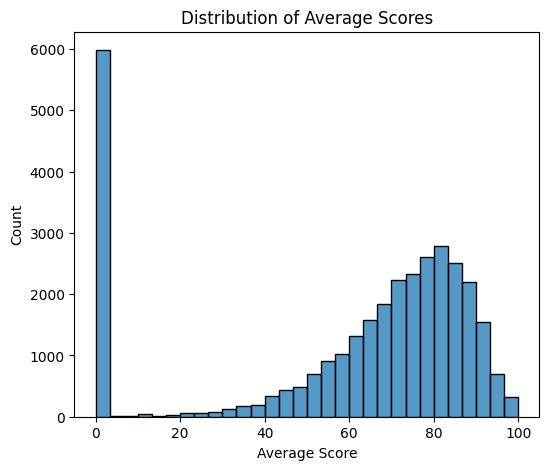

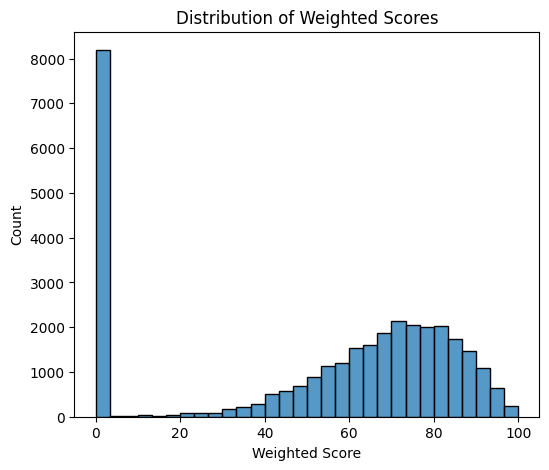

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.histplot(student_data['avg_score'], bins=30)
plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,5))
sns.histplot(student_data['weighted_score'], bins=30)
plt.title("Distribution of Weighted Scores")
plt.xlabel("Weighted Score")
plt.ylabel("Count")
plt.show()


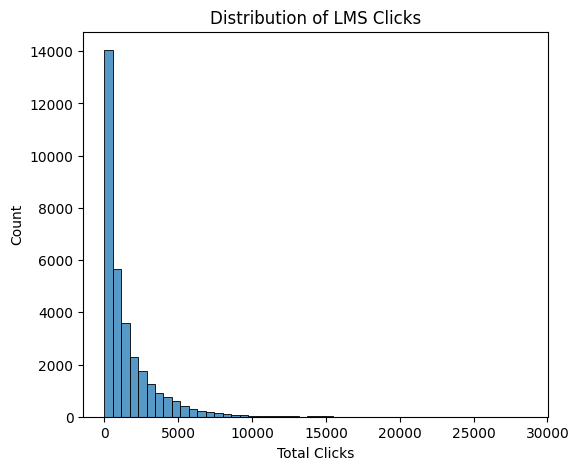

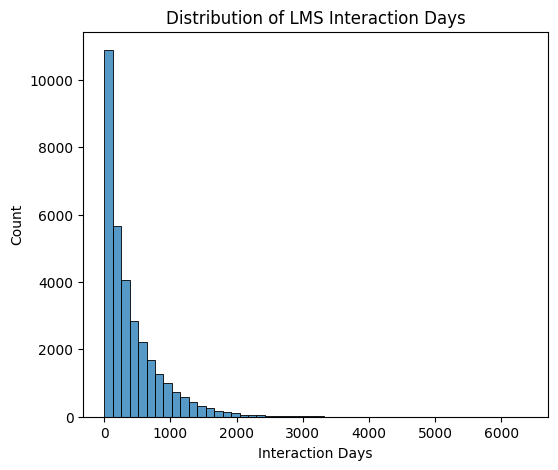

In [ ]:
plt.figure(figsize=(6,5))
sns.histplot(student_data['sum_click'], bins=50)
plt.title("Distribution of LMS Clicks")
plt.xlabel("Total Clicks")
plt.show()

plt.figure(figsize=(6,5))
sns.histplot(student_data['interaction_days'], bins=50)
plt.title("Distribution of LMS Interaction Days")
plt.xlabel("Interaction Days")
plt.show()


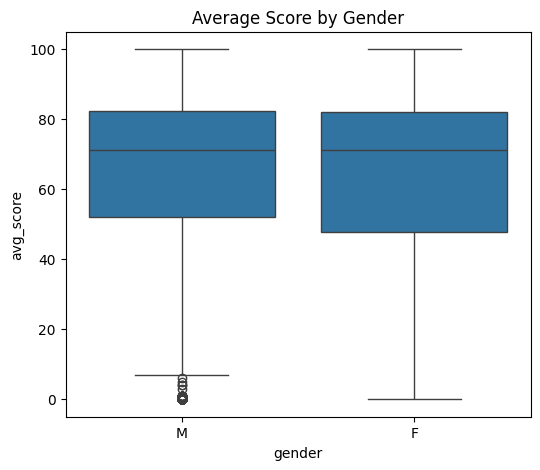

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(data=student_data, x='gender', y='avg_score')
plt.title("Average Score by Gender")
plt.show()


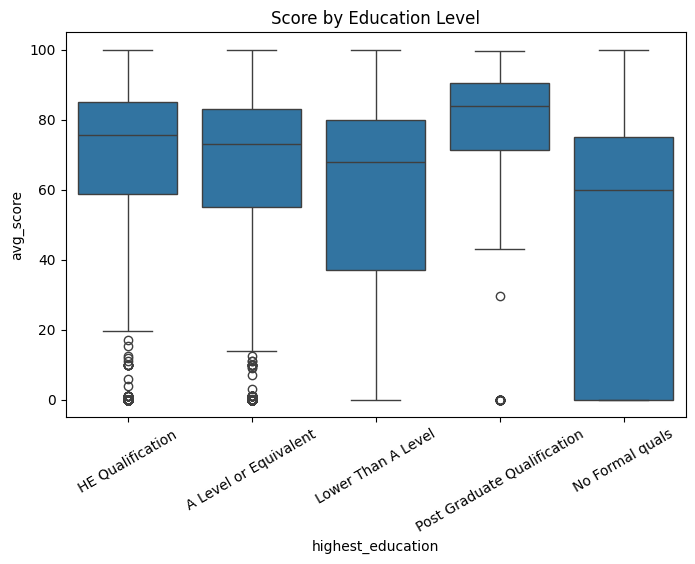

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=student_data, x='highest_education', y='avg_score')
plt.xticks(rotation=30)
plt.title("Score by Education Level")
plt.show()


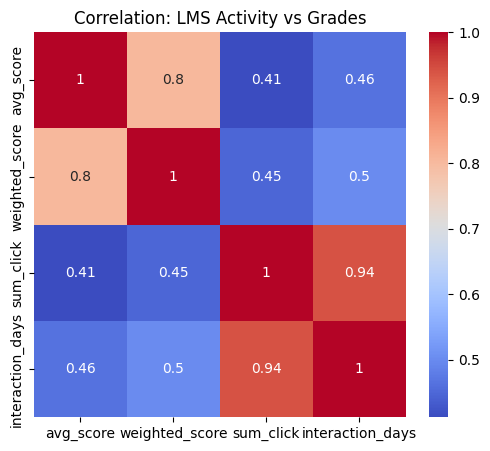

In [ ]:
corr = student_data[['avg_score','weighted_score','sum_click','interaction_days']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: LMS Activity vs Grades")
plt.show()


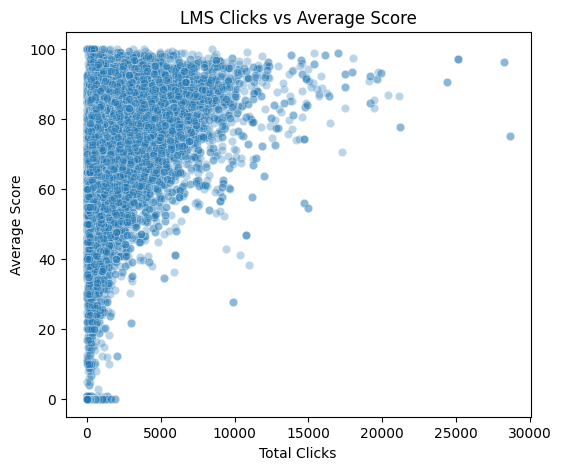

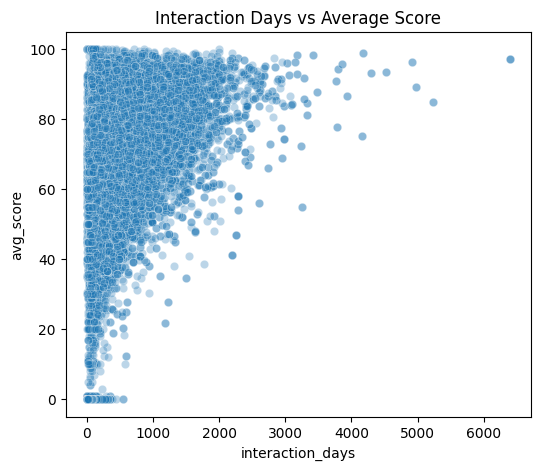

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=student_data, x='sum_click', y='avg_score', alpha=0.3)
plt.title("LMS Clicks vs Average Score")
plt.xlabel("Total Clicks")
plt.ylabel("Average Score")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(data=student_data, x='interaction_days', y='avg_score', alpha=0.3)
plt.title("Interaction Days vs Average Score")
plt.show()


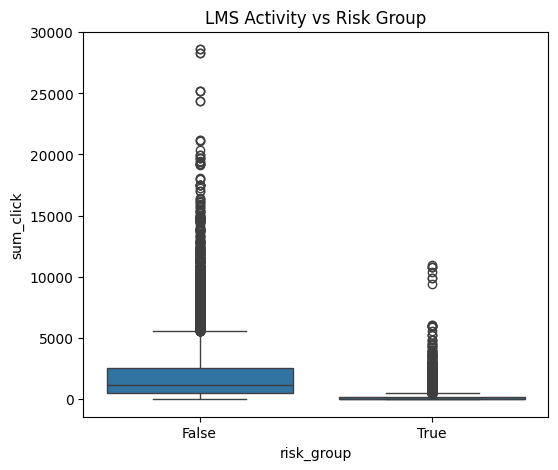

In [ ]:
student_data['risk_group'] = student_data['avg_score'] < 50

plt.figure(figsize=(6,5))
sns.boxplot(data=student_data, x='risk_group', y='sum_click')
plt.title("LMS Activity vs Risk Group")
plt.show()


In [ ]:
# ===== Cohort Grade Statistics =====

cohort_stats_gender = student_data.groupby('gender')['avg_score'].describe()
cohort_stats_region = student_data.groupby('region')['avg_score'].describe()
cohort_stats_education = student_data.groupby('highest_education')['avg_score'].describe()
cohort_stats_age = student_data.groupby('age_band')['avg_score'].describe()

print("Grade Stats by Gender")
print(cohort_stats_gender)

print("\nGrade Stats by Region")
print(cohort_stats_region)

print("\nGrade Stats by Education")
print(cohort_stats_education)

print("\nGrade Stats by Age Band")
print(cohort_stats_age)


Grade Stats by Gender
          count       mean        std  min        25%        50%    75%    max
gender                                                                        
F       14718.0  58.811120  32.064391  0.0  47.857143  71.250000  82.20  100.0
M       17875.0  60.469531  30.689656  0.0  52.033333  71.333333  82.25  100.0

Grade Stats by Region
                       count       mean        std  min        25%        50%  \
region                                                                          
East Anglian Region   3340.0  59.793040  31.472078  0.0  51.625000  71.750000   
East Midlands Region  2365.0  58.663038  32.003167  0.0  47.250000  71.333333   
Ireland               1184.0  65.973078  25.750230  0.0  60.769231  73.333333   
London Region         3216.0  55.478770  32.759637  0.0  38.750000  68.000000   
North Region          1823.0  60.438849  32.038925  0.0  48.541667  72.333333   
North Western Region  2906.0  55.506481  32.561631  0.0  39.500000  67.7

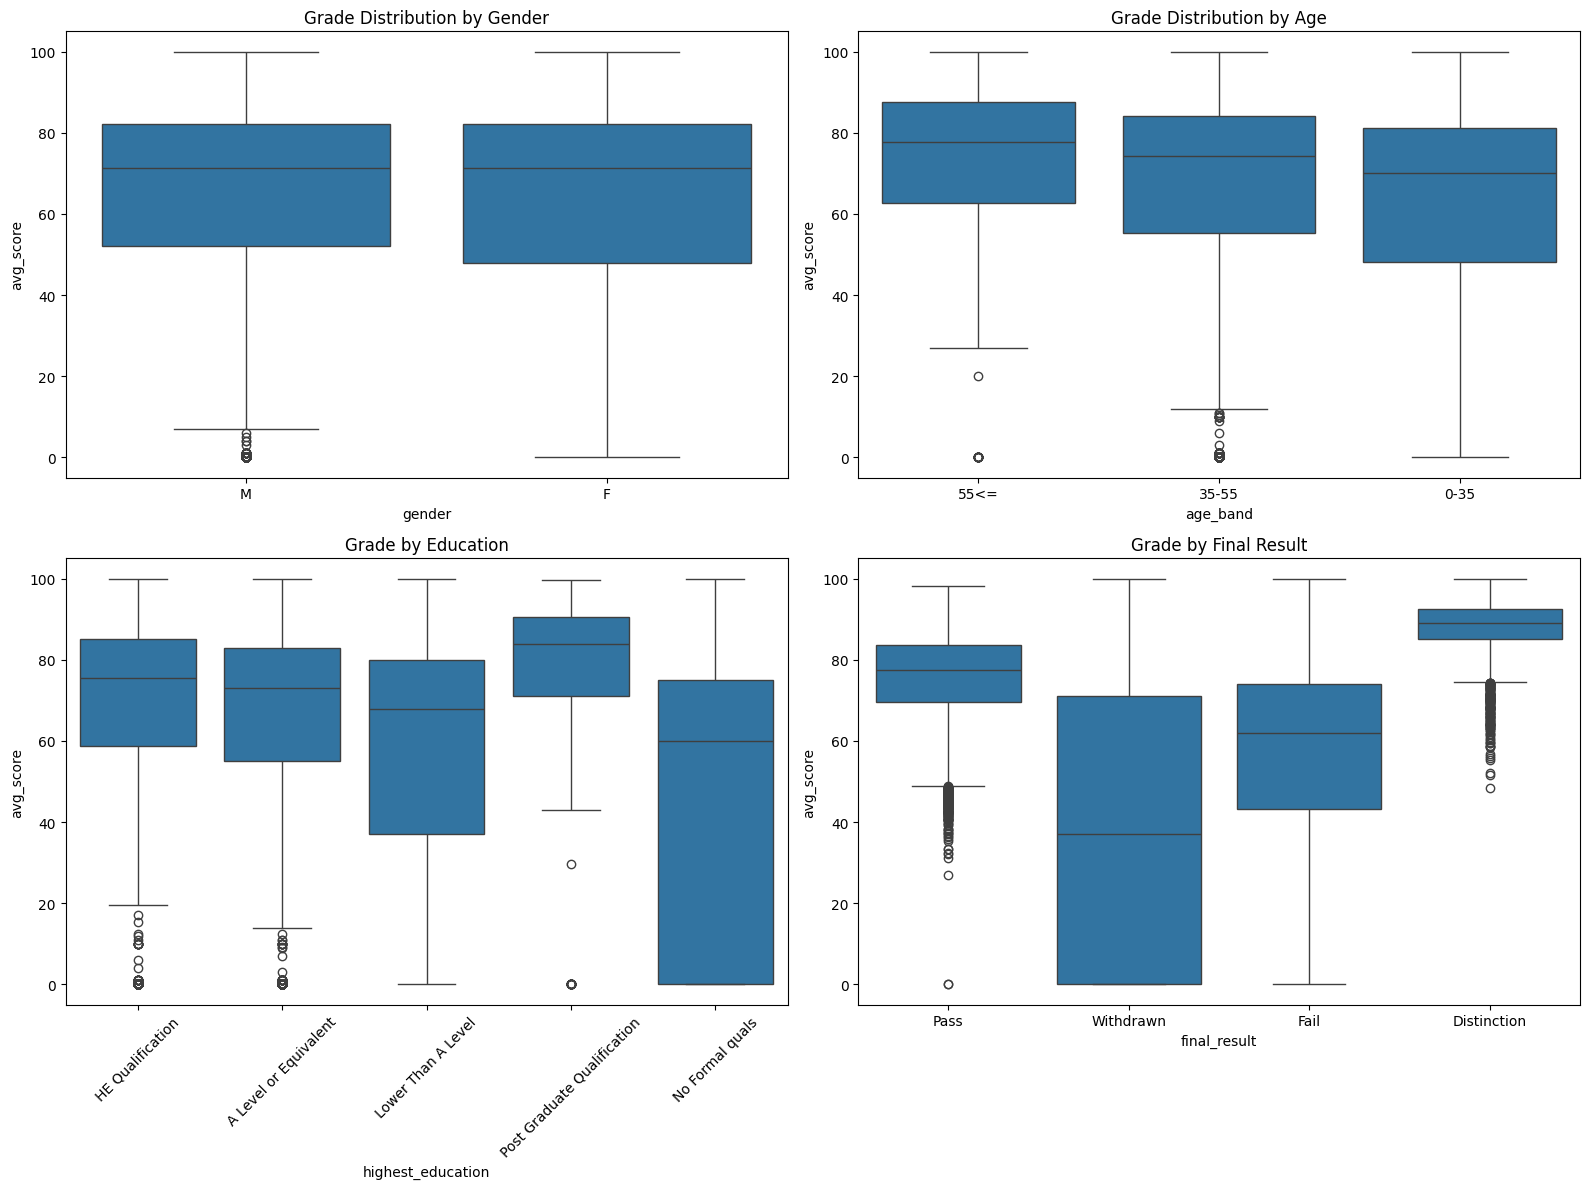

In [ ]:
# ===== Cohort Comparison Plots =====

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(x='gender', y='avg_score', data=student_data, ax=axes[0,0])
axes[0,0].set_title("Grade Distribution by Gender")

sns.boxplot(x='age_band', y='avg_score', data=student_data, ax=axes[0,1])
axes[0,1].set_title("Grade Distribution by Age")

sns.boxplot(x='highest_education', y='avg_score', data=student_data, ax=axes[1,0])
axes[1,0].set_title("Grade by Education")
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(x='final_result', y='avg_score', data=student_data, ax=axes[1,1])
axes[1,1].set_title("Grade by Final Result")

plt.tight_layout()
plt.show()


Dataset Shape: (32593, 18)

Weighted Score Summary:
count    32593.000000
mean        52.296326
std         33.241403
min          0.000000
25%          0.000000
50%         64.500000
75%         78.291667
max        100.000000
Name: weighted_score, dtype: float64


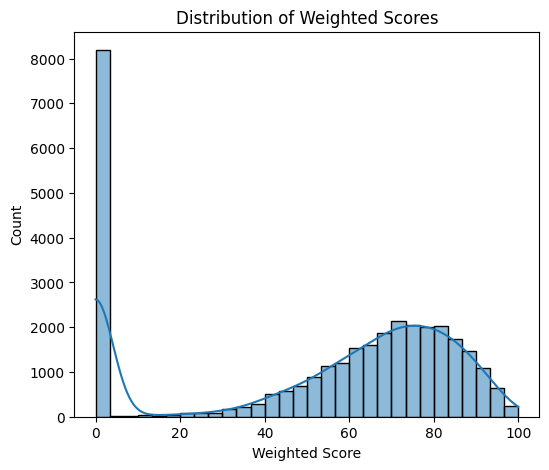

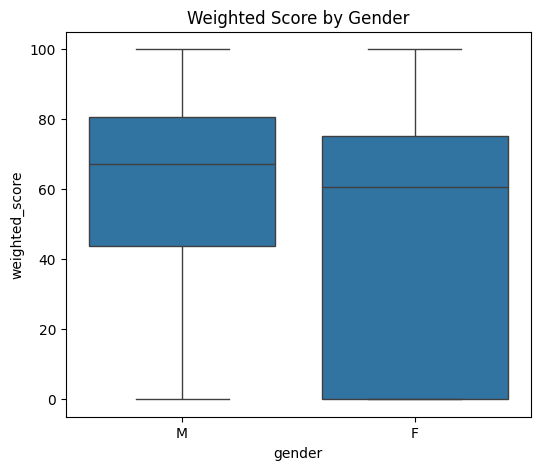

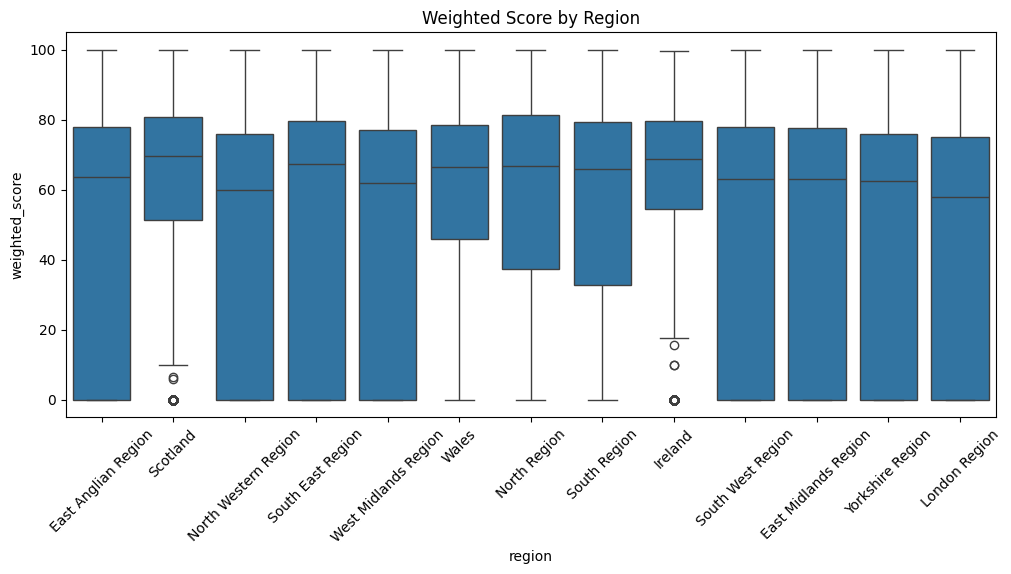

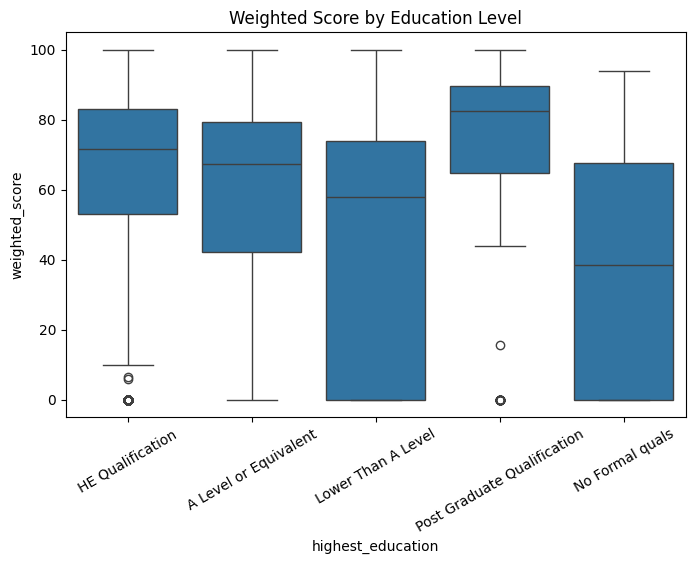

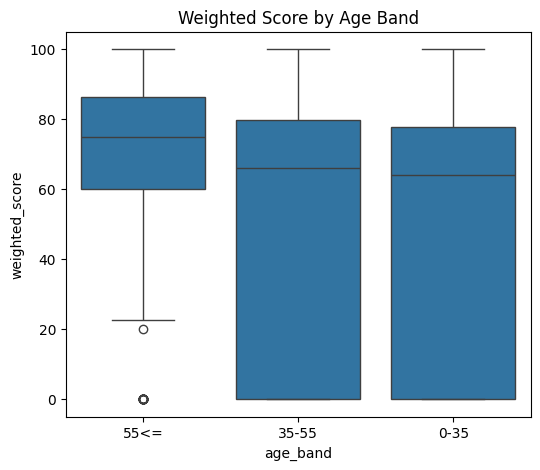

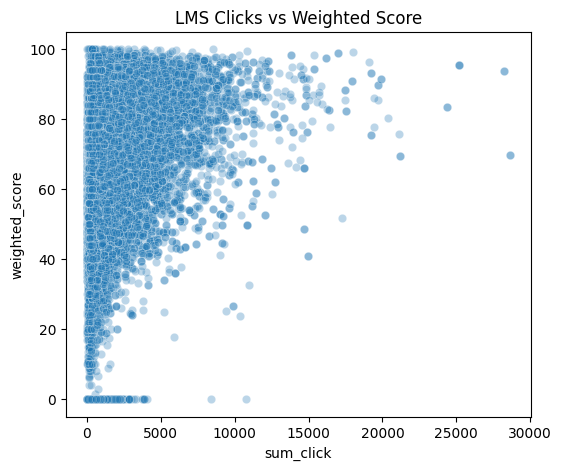

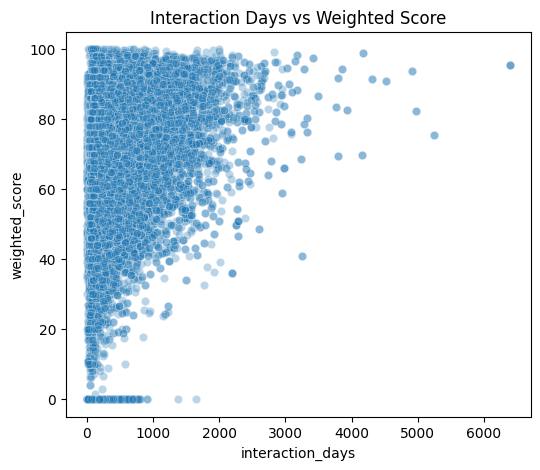

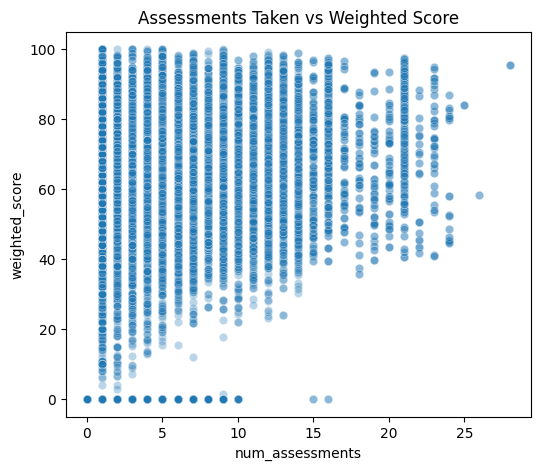

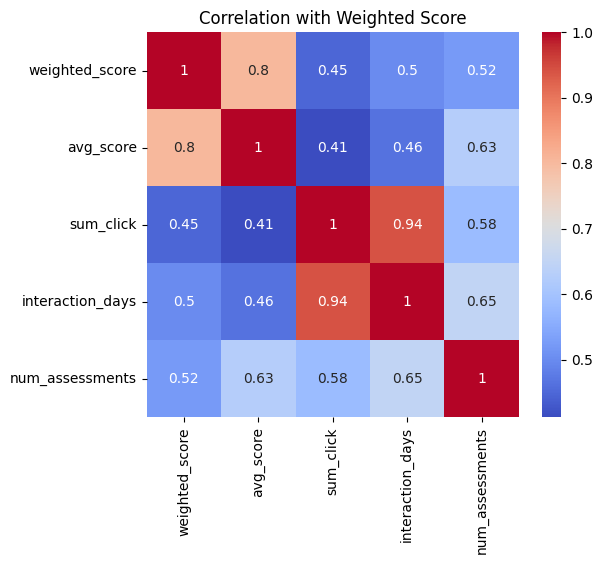


Weighted Score by Gender
          count       mean        std  min        25%        50%        75%  \
gender                                                                        
F       14718.0  46.891580  34.426782  0.0   0.000000  60.631579  75.297917   
M       17875.0  56.746512  31.545983  0.0  43.707865  67.300000  80.556415   

          max  
gender         
F       100.0  
M       100.0  

Weighted Score by Region
                       count       mean        std  min        25%        50%  \
region                                                                          
East Anglian Region   3340.0  50.669786  33.953308  0.0   0.000000  63.686047   
East Midlands Region  2365.0  50.065996  34.178500  0.0   0.000000  63.000000   
Ireland               1184.0  61.559457  26.322772  0.0  54.487500  68.812500   
London Region         3216.0  46.578118  34.292920  0.0   0.000000  58.015000   
North Region          1823.0  55.570430  33.276606  0.0  37.166667  66.800000   


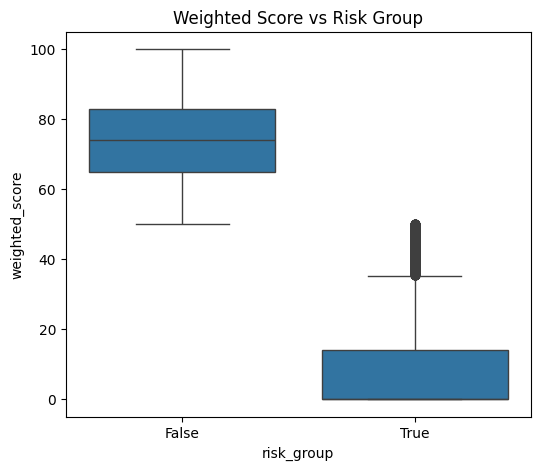


Risk Group Counts:
risk_group
False    21585
True     11008
Name: count, dtype: int64

✅ Weighted Score EDA Completed


In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("Dataset Shape:", student_data.shape)
print("\nWeighted Score Summary:")
print(student_data['weighted_score'].describe())

plt.figure(figsize=(6,5))
sns.histplot(student_data['weighted_score'], bins=30, kde=True)
plt.title("Distribution of Weighted Scores")
plt.xlabel("Weighted Score")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(6,5))
sns.boxplot(data=student_data, x='gender', y='weighted_score')
plt.title("Weighted Score by Gender")
plt.show()


plt.figure(figsize=(12,5))
sns.boxplot(data=student_data, x='region', y='weighted_score')
plt.xticks(rotation=45)
plt.title("Weighted Score by Region")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(data=student_data, x='highest_education', y='weighted_score')
plt.xticks(rotation=30)
plt.title("Weighted Score by Education Level")
plt.show()


plt.figure(figsize=(6,5))
sns.boxplot(data=student_data, x='age_band', y='weighted_score')
plt.title("Weighted Score by Age Band")
plt.show()


plt.figure(figsize=(6,5))
sns.scatterplot(data=student_data, x='sum_click', y='weighted_score', alpha=0.3)
plt.title("LMS Clicks vs Weighted Score")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(data=student_data, x='interaction_days', y='weighted_score', alpha=0.3)
plt.title("Interaction Days vs Weighted Score")
plt.show()


plt.figure(figsize=(6,5))
sns.scatterplot(data=student_data, x='num_assessments', y='weighted_score', alpha=0.3)
plt.title("Assessments Taken vs Weighted Score")
plt.show()


corr = student_data[['weighted_score','avg_score',
                     'sum_click','interaction_days',
                     'num_assessments']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation with Weighted Score")
plt.show()


print("\nWeighted Score by Gender")
print(student_data.groupby('gender')['weighted_score'].describe())

print("\nWeighted Score by Region")
print(student_data.groupby('region')['weighted_score'].describe())

print("\nWeighted Score by Education")
print(student_data.groupby('highest_education')['weighted_score'].describe())

print("\nWeighted Score by Age Band")
print(student_data.groupby('age_band')['weighted_score'].describe())


student_data['risk_group'] = student_data['weighted_score'] < 50

plt.figure(figsize=(6,5))
sns.boxplot(data=student_data, x='risk_group', y='weighted_score')
plt.title("Weighted Score vs Risk Group")
plt.show()

print("\nRisk Group Counts:")
print(student_data['risk_group'].value_counts())



In [ ]:
# ===== Correlation Analysis =====

corr_matrix = student_data[['sum_click','interaction_days','avg_score','num_assessments']].corr()

print("Correlation Matrix:")
print(corr_matrix)


In [ ]:
# ===== Scatter: LMS Activity vs Grade =====

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(x='sum_click', y='avg_score', data=student_data, alpha=0.3, ax=axes[0])
axes[0].set_title("Total Clicks vs Avg Score")

sns.scatterplot(x='interaction_days', y='avg_score', data=student_data, alpha=0.3, ax=axes[1])
axes[1].set_title("Interaction Days vs Avg Score")

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
student_data.to_csv("student_dashboard_data.csv", index=False)
student_data.info()

In [ ]:
student_data.to_csv("student_dashboard_data_final.csv", index=False)


In [ ]:
student_data.columns


In [ ]:
# Engagement level from clicks
student_data['engagement_level'] = pd.cut(
    student_data['sum_click'],
    bins=[0, 100, 500, 2000, float('inf')],
    labels=['Very_Low', 'Low', 'Medium', 'High']
)

# Activity level from days
student_data['activity_level'] = pd.cut(
    student_data['interaction_days'],
    bins=[0, 10, 30, 60, float('inf')],
    labels=['Inactive', 'Low_Active', 'Active', 'Very_Active']
)

# Performance level from score
student_data['performance_level'] = pd.cut(
    student_data['avg_score'],
    bins=[-1, 40, 65, 85, 100],
    labels=['Fail', 'Pass', 'Good', 'Excellent']
)

# Assessment participation
student_data['assessment_participation'] = pd.cut(
    student_data['num_assessments'],
    bins=[0, 3, 6, 10, float('inf')],
    labels=['Very_Low', 'Low', 'Medium', 'High']
)


In [ ]:
student_data.columns


In [ ]:
student_data.to_csv("student_dashboard_data_f2.csv", index=False)


In [ ]:



















fig, axes = plt.subplots(2, 3, figsize=(18, 12))

student_info['gender'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')

student_info['region'].value_counts().head(10).plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Top 10 Regions Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Region')
axes[0, 1].set_ylabel('Count')

student_info['highest_education'].value_counts().plot(kind='bar', ax=axes[0, 2], color='lightgreen')
axes[0, 2].set_title('Education Level Distribution', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Education Level')
axes[0, 2].set_ylabel('Count')

student_info['age_band'].value_counts().plot(kind='bar', ax=axes[1, 0], color='gold')
axes[1, 0].set_title('Age Band Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Age Band')
axes[1, 0].set_ylabel('Count')

student_info['final_result'].value_counts().plot(kind='bar', ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Final Result Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Final Result')
axes[1, 1].set_ylabel('Count')

student_info['disability'].value_counts().plot(kind='pie', ax=axes[1, 2], autopct='%1.1f%%')
axes[1, 2].set_title('Disability Distribution', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('')

plt.tight_layout()
plt.savefig('demographics_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:


vle_summary = student_vle.groupby('id_student').agg({
    'sum_click': 'sum',
    'date': 'count'
}).rename(columns={'date': 'interaction_days'})

print("VLE Interaction Summary:")
print(vle_summary.describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(vle_summary['sum_click'], bins=50, color='teal', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution of Total Clicks', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Clicks')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 5000)

axes[1].hist(vle_summary['interaction_days'], bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Interaction Days', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Interaction Days')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('vle_interaction_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
assessment_summary = student_assessment.groupby('id_student')['score'].agg(['mean', 'count']).reset_index()
assessment_summary.columns = ['id_student', 'avg_score', 'num_assessments']

print("Assessment Summary:")
print(assessment_summary.describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(assessment_summary['avg_score'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution of Average Assessment Scores', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Score')
axes[0].set_ylabel('Frequency')

axes[1].hist(assessment_summary['num_assessments'], bins=20, color='brown', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Number of Assessments Taken', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Assessments')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('assessment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
student_data = student_info.copy()

student_data = student_data.merge(vle_summary, on='id_student', how='left')
student_data = student_data.merge(assessment_summary, on='id_student', how='left')

student_data['sum_click'].fillna(0, inplace=True)
student_data['interaction_days'].fillna(0, inplace=True)
student_data['avg_score'].fillna(0, inplace=True)
student_data['num_assessments'].fillna(0, inplace=True)

student_data['imd_band'].fillna('Unknown', inplace=True)

print("Integrated Dataset Shape:", student_data.shape)
print("\nMissing Values After Integration:")
print(student_data.isnull().sum())
print("\nIntegrated Dataset Sample:")
print(student_data.head())

In [ ]:


student_data['engagement_level'] = pd.cut(student_data['sum_click'],
                                           bins=[0, 100, 500, 2000, float('inf')],
                                           labels=['Very_Low', 'Low', 'Medium', 'High'])

student_data['performance_level'] = pd.cut(student_data['avg_score'],
                                             bins=[-1, 40, 65, 85, 100],
                                             labels=['Fail', 'Pass', 'Good', 'Excellent'])

student_data['activity_level'] = pd.cut(student_data['interaction_days'],
                                          bins=[0, 10, 30, 60, float('inf')],
                                          labels=['Inactive', 'Low_Active', 'Active', 'Very_Active'])

student_data['assessment_participation'] = pd.cut(student_data['num_assessments'],
                                                    bins=[0, 3, 6, 10, float('inf')],
                                                    labels=['Very_Low', 'Low', 'Medium', 'High'])

print("Feature Engineering Complete!")
print("\nNew Features Sample:")
print(student_data[['engagement_level', 'performance_level', 'activity_level', 'assessment_participation']].head(10))

